In [20]:
import cv2
import matplotlib.pylab as plt
import numpy as np
import pandas as pd

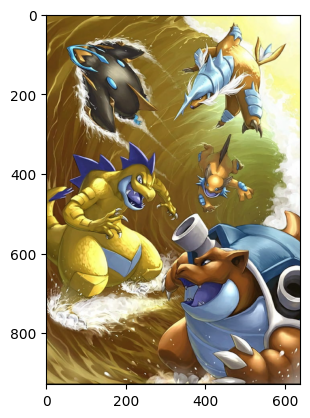

In [21]:
water = cv2.imread('water.jpg')
plt.imshow(water)
plt.show()

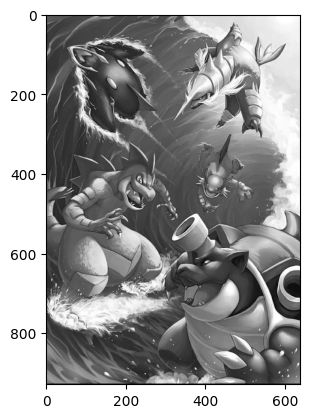

In [22]:
water_grey = cv2.cvtColor(water, cv2.COLOR_BGR2GRAY)
plt.imshow(water_grey, cmap='gray')
plt.show()

In [23]:
def ekualisasi_histogram(citra):
    panjang, lebar = citra.shape

    histogram = np.zeros(256, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(histogram[:i+1])

    cdf_min = cdf[cdf > 0].min() if np.any(cdf > 0) else 0
    cdf_norm = np.round((cdf - cdf_min) / (panjang * lebar - cdf_min) * 255).astype(int)

    hasil = np.zeros_like(citra, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil

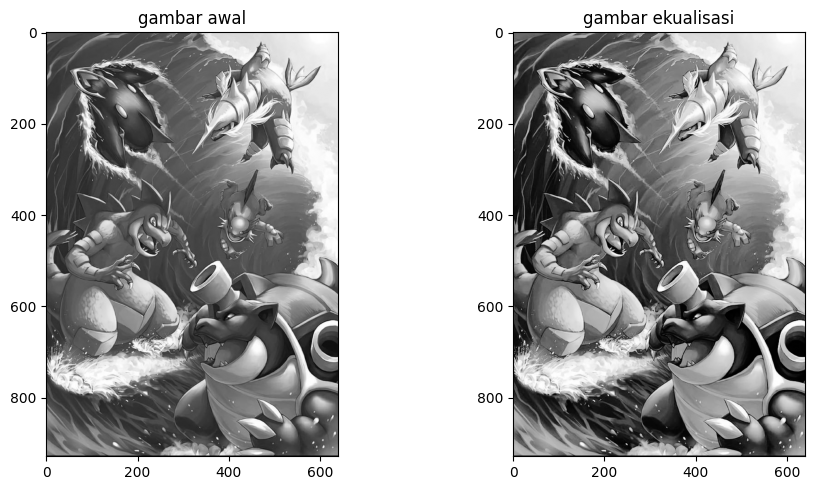

In [24]:
panjang, lebar = water_grey.shape
hasil = ekualisasi_histogram(water_grey)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(water_grey, cmap='gray')
plt.title("gambar awal")

plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap='gray')
plt.title("gambar ekualisasi")

plt.tight_layout()
plt.show()

In [25]:
def tampilkan_histogram(citra, warna='black'):
    histogram = np.zeros(256, dtype=int)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            nilai = citra[i, j]
            histogram[nilai] += 1
    plt.figure(figsize=(10, 5))
    plt.bar(range(256), histogram, width=1, color=warna)
    plt.title('Histogram Citra')
    plt.xlabel('Intensitas Piksel')
    plt.ylabel('Jumlah Piksel')
    plt.grid(True)
    plt.show()
    return histogram

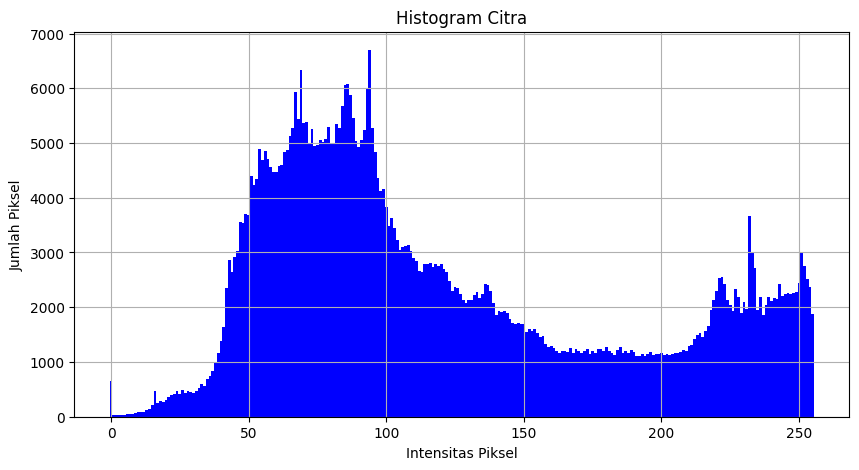

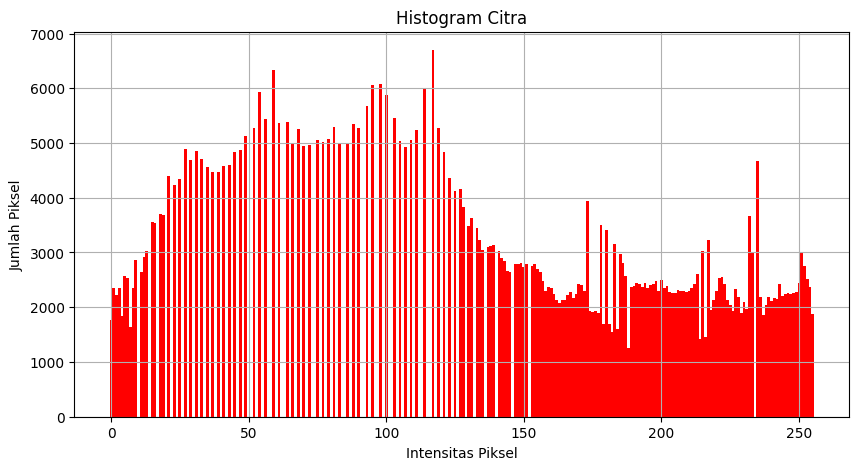

In [26]:
hist_awal = tampilkan_histogram(water_grey, 'blue')
hist_equalized = tampilkan_histogram(hasil, 'red')

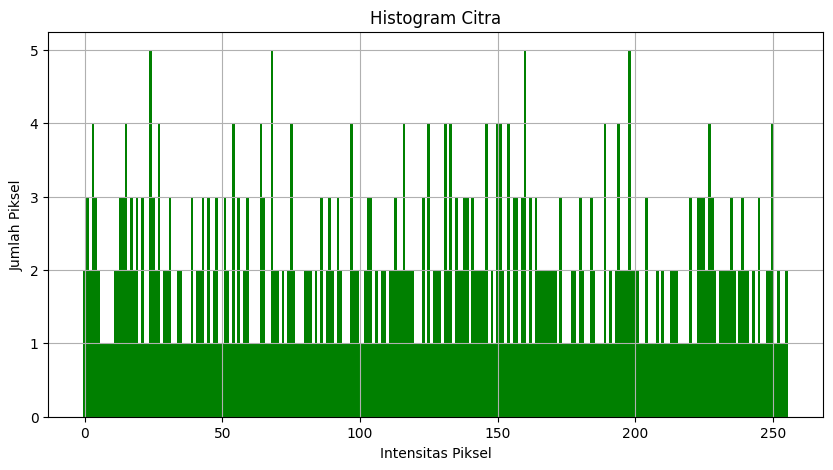

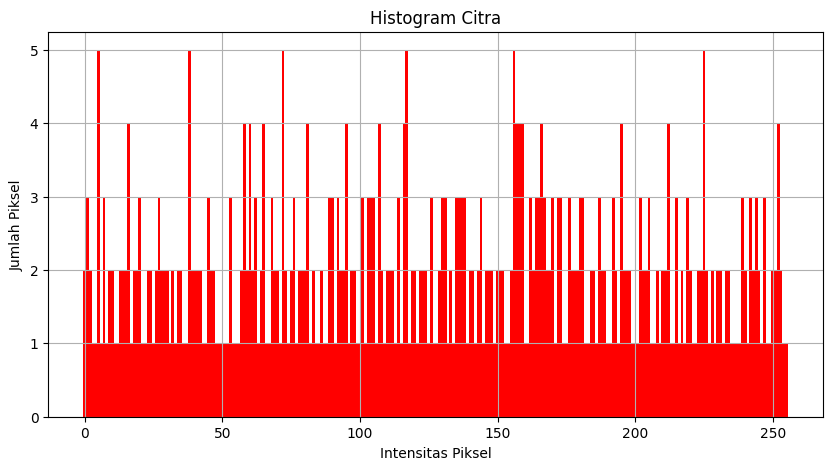

In [40]:
target1 = pd.read_csv('target 1.csv')
target2 = pd.read_csv('target 2.csv')

target1_grey = target1.values.astype(np.uint8)
target2_grey = target2.values.astype(np.uint8)

hist_target1 = tampilkan_histogram(target1_grey, 'green')
hist_target2 = tampilkan_histogram(target2_grey, 'red')


In [41]:
def spesifikasi_histogram(citra_sumber, citra_target):

    panjang_sumber, lebar_sumber = citra_sumber.shape
    panjang_target, lebar_target = citra_target.shape

    histogram_sumber = np.zeros(256, dtype=int)
    for i in range(panjang_sumber):
        for j in range(lebar_sumber):
            nilai = citra_sumber[i, j]
            histogram_sumber[nilai] += 1

    histogram_target = np.zeros(256, dtype=int)
    for i in range(panjang_target):
        for j in range(lebar_target):
            nilai = citra_target[i, j]
            histogram_target[nilai] += 1

    cdf_sumber = np.zeros(256, dtype=int)
    for i in range(256):
        cdf_sumber[i] = np.sum(histogram_sumber[:i+1])

    cdf_sumber_min = cdf_sumber[cdf_sumber > 0].min() if np.any(cdf_sumber > 0) else 0
    cdf_sumber_norm = (cdf_sumber - cdf_sumber_min) / (panjang_sumber * lebar_sumber - cdf_sumber_min)

    cdf_target = np.zeros(256, dtype=int)
    for i in range(256):
        cdf_target[i] = np.sum(histogram_target[:i+1])

    cdf_target_min = cdf_target[cdf_target > 0].min() if np.any(cdf_target > 0) else 0
    cdf_target_norm = (cdf_target - cdf_target_min) / (panjang_target * lebar_target - cdf_target_min)

    pemetaan = np.zeros(256, dtype=int)
    for i in range(256):
        idx = np.argmin(np.abs(cdf_target_norm - cdf_sumber_norm[i]))
        pemetaan[i] = idx

    hasil = np.zeros_like(citra_sumber)
    for i in range(panjang_sumber):
        for j in range(lebar_sumber):
            nilai = citra_sumber[i, j]
            hasil[i, j] = pemetaan[nilai]

    return hasil



(np.float64(-0.5), np.float64(638.5), np.float64(928.5), np.float64(-0.5))

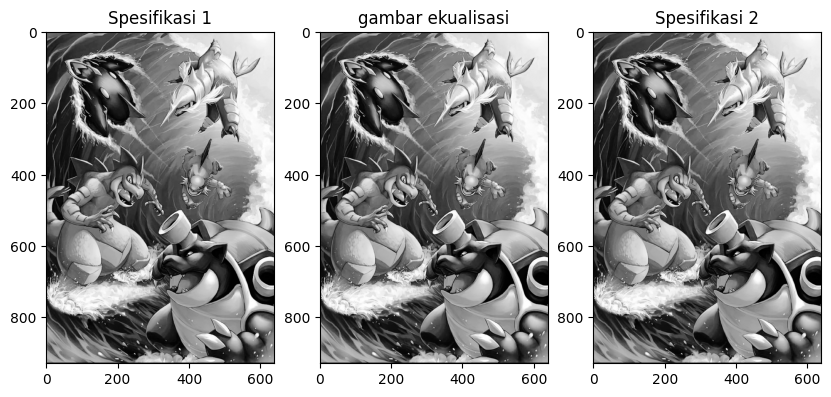

In [45]:
spek1 = spesifikasi_histogram(hasil, target1_grey)
spek2 = spesifikasi_histogram(hasil, target2_grey)

plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1)
plt.imshow(spek1, cmap='gray')
plt.title("Spesifikasi 1")
plt.axis('on')

plt.subplot(1, 3, 2)
plt.title("gambar ekualisasi")
plt.imshow(hasil, cmap='gray')
plt.axis('on')

plt.subplot(1, 3, 3)
plt.title("Spesifikasi 2")
plt.imshow(spek2, cmap='gray')
plt.axis('on')

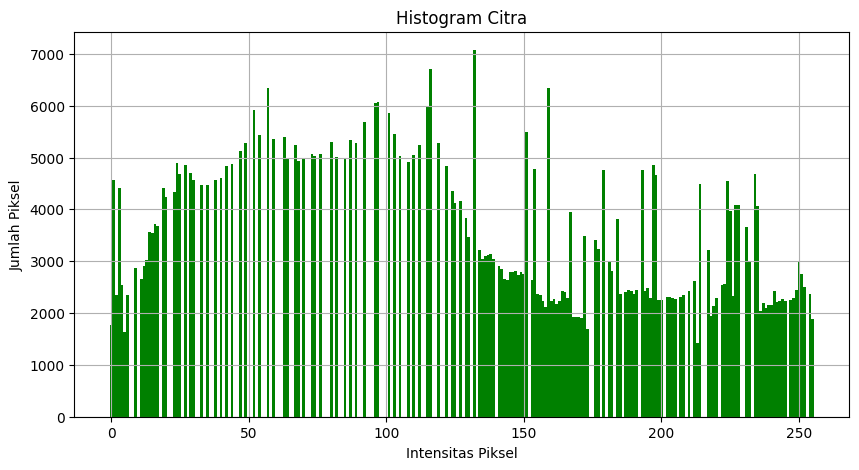

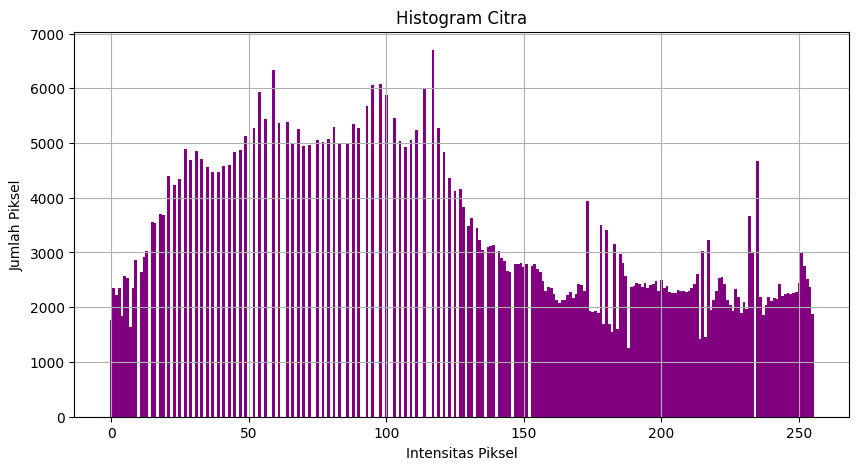

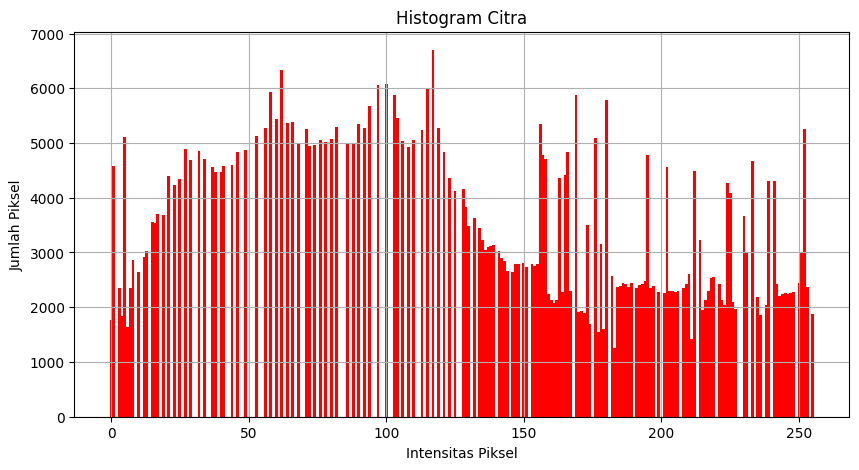

In [46]:
hist_spek1 = tampilkan_histogram(spek1, 'green')
hist_ekual = tampilkan_histogram(hasil, 'purple')
hist_spek2 = tampilkan_histogram(spek2, 'red')

(np.float64(-0.5), np.float64(638.5), np.float64(928.5), np.float64(-0.5))

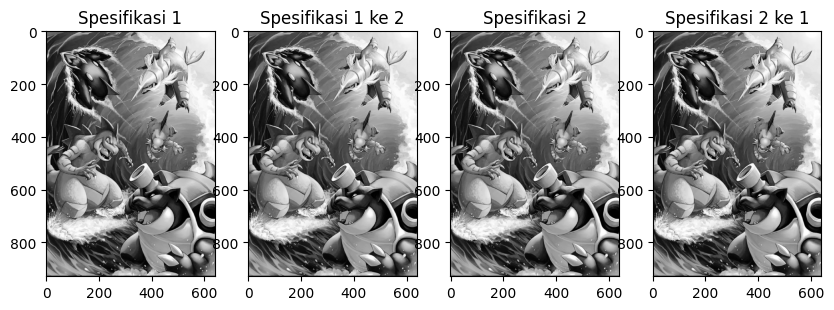

In [47]:
spek1_2 = spesifikasi_histogram(spek1, target2_grey)
spek2_1 = spesifikasi_histogram(spek2, target1_grey)

plt.figure(figsize=(10, 10))

plt.subplot(1, 4, 1)
plt.imshow(spek1, cmap='gray')
plt.title("Spesifikasi 1")
plt.axis('on')

plt.subplot(1, 4, 2)
plt.title("Spesifikasi 1 ke 2")
plt.imshow(spek1_2, cmap='gray')
plt.axis('on')

plt.subplot(1, 4, 3)
plt.title("Spesifikasi 2")
plt.imshow(spek2, cmap='gray')
plt.axis('on')

plt.subplot(1, 4, 4)
plt.title("Spesifikasi 2 ke 1") 
plt.imshow(spek2_1, cmap='gray')
plt.axis('on')

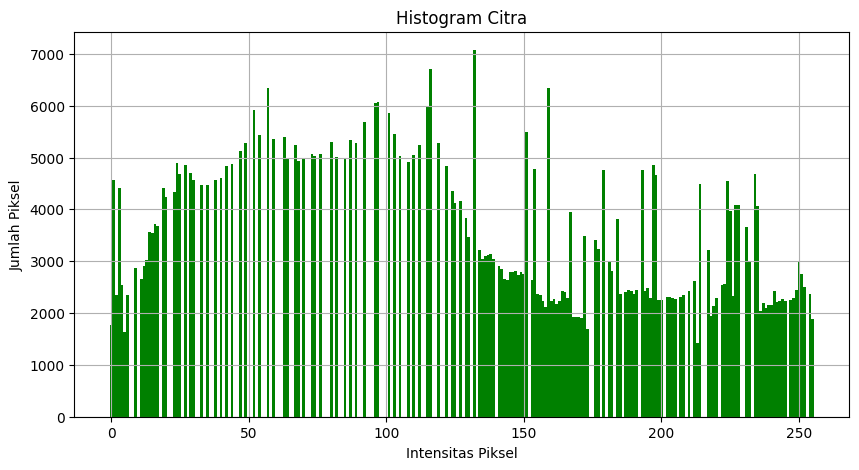

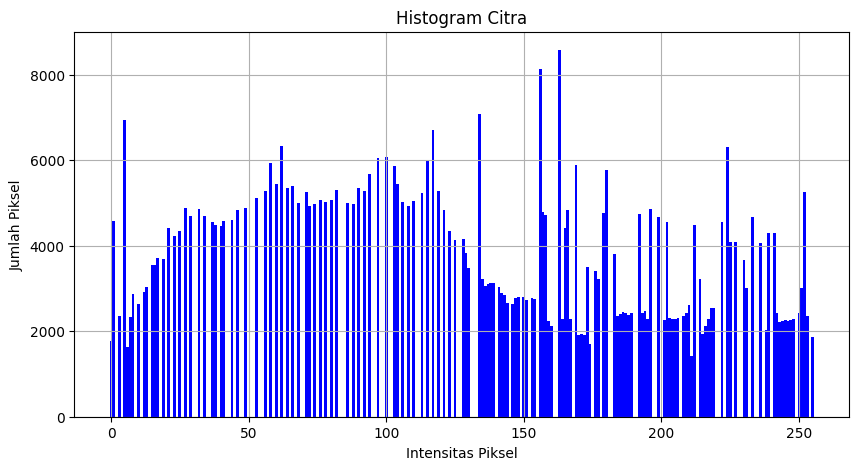

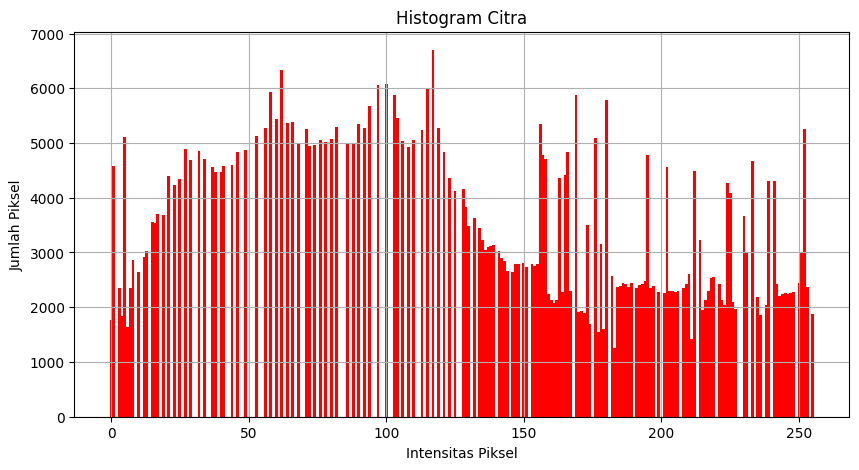

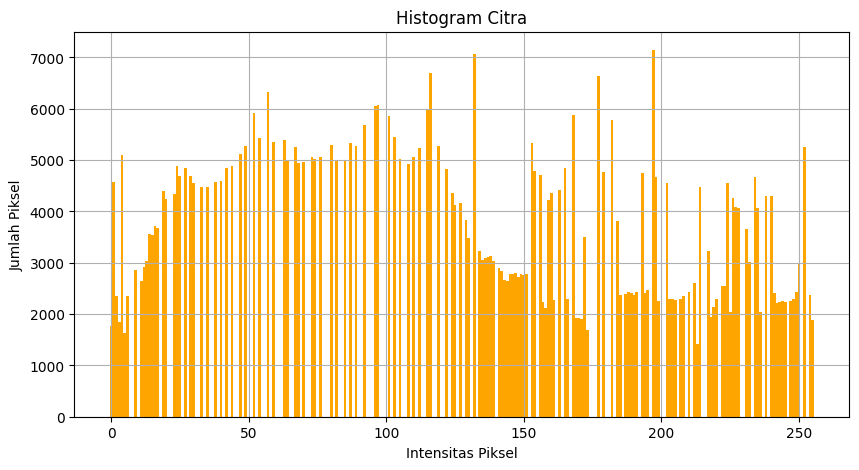

In [48]:
hist_spek1 = tampilkan_histogram(spek1, 'green')
hist_spek1_2 = tampilkan_histogram(spek1_2, 'blue')
hist_spek2 = tampilkan_histogram(spek2, 'red')
hist_spek2_1 = tampilkan_histogram(spek2_1, 'orange')